#### Here we can create any content for now we will create a X(tweet) Post

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Annotated
import operator
import os
from dotenv import load_dotenv
load_dotenv()
GEMINI_API = os.getenv('GEMINI_API')

In [ ]:
class TweetEvaluator(BaseModel):
    evaluation: Literal["approved", 'needs_improvement'] = Field(..., description="Final evaluation result")
    feedback: str = Field(..., description="Constructive feedback for the tweet")
    # score: int = Field(..., ge=0, le=5, description="Total score from rebric (0-5)")



class TweetState(TypedDict):
    tweet: str
    topic: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int = 0
    max_iteration: int = 3

    history: Annotated[list[dict[str,str]], operator.add]

In [ ]:
llm = ChatGoogleGenerativeAI(api_key = GEMINI_API, model = "gemini-3.1-flash-lite")

In [ ]:
def generate_tweet(state: TweetState) -> TweetState:
    topic = state['topic']
    prompt = [
        SystemMessage(content="You are funny clever Twitter/X influencer"),
        HumanMessage(content=f"""
Write a short, original and hallarious tweet on the topic {topic}.

Rules:
- Do not use question answer format.
- Max 280 characters only.- 
- Use observational humor, irony,sarcasm or cultural reference.
- Think in meme logic, punchlines, or relatable takes.
- Use simple day to day english
""")
    ]

    responce = llm.invoke(prompt).content[0]['text']
    return {'tweet' : responce}

def evaluate_tweet(state: TweetState) -> TweetState:
    tweet = state['tweet']

    prompt = [
        SystemMessage(content="You are a ruthless, no-laugh-given twitter critic. You evaluate based on humor, originality, virality, and tweet format"),
        HumanMessage(content=f"""
Evaluate the following tweet:
{tweet}

Use the critic below to evaluate the tweet:

1. Originality - Is this fresh or you have seen it hundreds time before?
2. Humor - Did is genuinely make you smile, laugh or chuckle?
3. Punchiness - Is it short, sharp and scroll stopping?
4. Virality Potential - Would people retweet or share it?
5. Format - Is it a well formed tweet (not a setup punchline joke, not a Q/A joke and under 280 characters)?

Auto rejech if:
- It's written in question format (e.g., "Why did..." or "What happnes when")
- It exeeds more the 280 characters.
- It reads like traditional setup-punchline jokes.
- Dont end with generac throwaway or deflating lines that weaken the humor (e.g., "Masterpieces of the aunty-uncle universe" or vague summaries)
""")
    ]

    response = llm.with_structured_output(TweetEvaluator).invoke(prompt)

    return {'evaluation': response.evaluation, "feedback": response.feedback, 'history':[{'tweet':tweet , "feedback": response.feedback}]}

def improve_tweet(state: TweetState) -> TweetState:
    topic, tweet, feedback, iteration = state['topic'], state['tweet'], state['feedback'], state['iteration']

    prompt = [
        SystemMessage(content="You puch up tweets for viralityand humor base on given feedback"),
        HumanMessage(content=f"""
Inprove the tweet based on the feeedback:
FEEDBACK: {feedback}

Topic: {topic}
Original tweet: {tweet}

Rewrite it as a short, viral-worthy tweet. Avoid Q/A style and stay under 280 characters
""")
    ]

    responce = llm.invoke(prompt).content[0]['text']
    iteration += 1
    return{"tweet": responce, "iteration": iteration}

def tweet_approved_or_not(state: TweetState)-> Literal['approved', 'needs_improvement']:
    evaluation, iteration, max_iteration = state['evaluation'], state['iteration'], state['max_iteration']

    if evaluation == "approved" or iteration>=max_iteration:
        return "approved"
    else:
        return "needs_improvement"


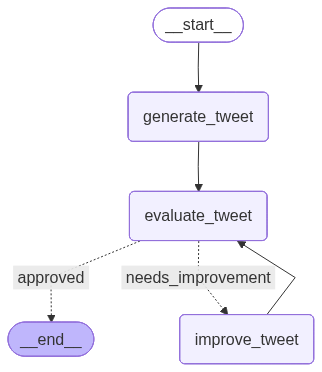

In [ ]:
graph = StateGraph(TweetState)

# Add Nodes
graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('improve_tweet', improve_tweet)

# Add Edges:
graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', tweet_approved_or_not, path_map={'approved': END, 'needs_improvement': "improve_tweet"})
graph.add_edge('improve_tweet', 'evaluate_tweet')

workflow = graph.compile()
workflow

In [ ]:
initial_state = {'topic': "NEET paper leak 2026", "iteration":0, 'max_iteration':3}
final_state = workflow.invoke(initial_state)

In [ ]:
final_state

{'tweet': 'To make this viral, you need to lean into the **dystopian absurdity** of the situation rather than trying to write a traditional "joke." Here are three options that hit that cynical, effortless tone:\n\n**Option 1: The "Corporate Pivot" (Best for engagement)**\nNTA isn\'t even trying to hide the business model anymore. Why leak the paper when you can just pivot to a monthly SaaS model? “NEET+ Premium” — pay 20k a month or get a 600 score in your DM. The education system is just an overpriced gacha game now. 🤡\n\n**Option 2: The Short & Sharp (Maximum shareability)**\nAt this point, NEET isn’t an exam, it’s just a subscription service with extra steps. Don’t study, just upgrade your plan.\n\n**Option 3: The Dry Observer (Highest "cynical" energy)**\nNTA really moved from "paper leaks" to "official distribution" and expected us not to notice the shift in the business model. It’s not an exam season anymore, it’s just a tiered pricing menu. 💀\n\n**Why these work:**\n*   **No "se